# War Prediction based on Social Media Analytics
## Russia-Ukraine War Analysis from YouTube Data

**Learning Outcome (LO1):** Demonstrate proficiency in collecting, cleaning, and storing social media data

**Objective:**
- Collect YouTube comments and video metadata from channels covering Russia-Ukraine war
- Clean and preprocess the collected data
- Store the processed data for further analysis and prediction modeling

- **Channel:** DW News (Russia-Ukraine War Coverage)
- **Collection Method:** YouTube Data API v3for simplicity)

## 1. Setup and Dependencies

In [ ]:
# Install required libraries
# !pip install google-api-python-client pandas numpy matplotlib seaborn textblob nltk sqlalchemy pymongo -q

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from googleapiclient.discovery import build
from textblob import TextBlob
import nltk
from sqlalchemy import create_engine
import sqlite3

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("✓ All libraries imported successfully!")
print("✓ NLTK data downloaded!")
print("\nReady for data collection...")

✓ All libraries imported successfully!
✓ NLTK data downloaded!

Ready for data collection...


## 2. Data Collection from YouTube

### 2.1 YouTube API Configuration

**Note:** To use YouTube Data API, you need:
1. Go to [Google Cloud Console](https://console.cloud.google.com/)
2. Create a new project or select existing one
3. Enable YouTube Data API v3
4. Create credentials (API Key)
5. Replace 'YOUR_API_KEY' below with your actual API key

In [ ]:
import os

# YouTube API Configuration

API_KEY = os.environ.get('YOUTUBE_API')  # Get API key from environment variable

# Example channel focusing on Russia-Ukraine war coverage
# You can use channels like: 
# - DW News: UCknLrEdhRCp1aegoMqRaCZg
# - Sky News: UCoMdktPbSTixAyNGwb-UYkQ

CHANNEL_ID = 'UCknLrEdhRCp1aegoMqRaCZg'  # DW News channel
SEARCH_QUERY = 'Russia Ukraine war'
MAX_VIDEOS = 5  # Keep it small for testing, increase later

In [4]:
# YouTube Data Collector Class
class YouTubeDataCollector:
    def __init__(self, api_key):
        self.youtube = build('youtube', 'v3', developerKey=api_key)
        self.videos_data = []
        self.comments_data = []
    
    def search_videos(self, channel_id, query, max_results=5):
        """Search for videos on a channel with specific keywords"""
        try:
            request = self.youtube.search().list(
                part='snippet',
                channelId=channel_id,
                q=query,
                maxResults=max_results,
                order='date',
                type='video'
            )
            response = request.execute()
            
            video_ids = [item['id']['videoId'] for item in response['items']]
            print(f"✓ Found {len(video_ids)} videos")
            return video_ids
        except Exception as e:
            print(f"Error searching videos: {e}")
            return []
    
    def get_video_details(self, video_ids):
        """Get detailed information about videos"""
        try:
            request = self.youtube.videos().list(
                part='snippet,statistics,contentDetails',
                id=','.join(video_ids)
            )
            response = request.execute()
            
            for item in response['items']:
                video_data = {
                    'video_id': item['id'],
                    'title': item['snippet']['title'],
                    'description': item['snippet']['description'],
                    'published_at': item['snippet']['publishedAt'],
                    'channel_title': item['snippet']['channelTitle'],
                    'view_count': int(item['statistics'].get('viewCount', 0)),
                    'like_count': int(item['statistics'].get('likeCount', 0)),
                    'comment_count': int(item['statistics'].get('commentCount', 0)),
                    'duration': item['contentDetails']['duration']
                }
                self.videos_data.append(video_data)
            
            print(f"✓ Collected details for {len(self.videos_data)} videos")
            return self.videos_data
        except Exception as e:
            print(f"Error getting video details: {e}")
            return []
    
    def get_video_comments(self, video_id, max_comments=100):
        """Get comments for a specific video"""
        comments = []
        try:
            request = self.youtube.commentThreads().list(
                part='snippet',
                videoId=video_id,
                maxResults=min(max_comments, 100),
                textFormat='plainText',
                order='relevance'
            )
            response = request.execute()
            
            for item in response['items']:
                comment = item['snippet']['topLevelComment']['snippet']
                comment_data = {
                    'video_id': video_id,
                    'comment_id': item['id'],
                    'comment_text': comment['textDisplay'],
                    'author': comment['authorDisplayName'],
                    'published_at': comment['publishedAt'],
                    'like_count': comment['likeCount'],
                    'reply_count': item['snippet']['totalReplyCount']
                }
                comments.append(comment_data)
            
            return comments
        except Exception as e:
            print(f"Error getting comments for video {video_id}: {e}")
            return []
    
    def collect_all_comments(self, video_ids, max_comments_per_video=50):
        """Collect comments from all videos"""
        for video_id in video_ids:
            comments = self.get_video_comments(video_id, max_comments_per_video)
            self.comments_data.extend(comments)
            print(f"  - Collected {len(comments)} comments from video {video_id}")
        
        print(f"\n✓ Total comments collected: {len(self.comments_data)}")
        return self.comments_data
    
    def get_data_as_dataframes(self):
        """Convert collected data to pandas DataFrames"""
        videos_df = pd.DataFrame(self.videos_data)
        comments_df = pd.DataFrame(self.comments_data)
        return videos_df, comments_df

print("✓ YouTubeDataCollector class created successfully!")

✓ YouTubeDataCollector class created successfully!


In [5]:
# Initialize collector and collect data
print("Starting data collection...\n")

# Create collector instance
collector = YouTubeDataCollector(API_KEY)

# Step 1: Search for videos
print("Step 1: Searching for videos...")
video_ids = collector.search_videos(CHANNEL_ID, SEARCH_QUERY, MAX_VIDEOS)

# Step 2: Get video details
print("\nStep 2: Collecting video details...")
videos_data = collector.get_video_details(video_ids)

# Step 3: Get comments
print("\nStep 3: Collecting comments...")
comments_data = collector.collect_all_comments(video_ids, max_comments_per_video=50)

# Convert to DataFrames
videos_df, comments_df = collector.get_data_as_dataframes()

print(f"\n{'='*60}")
print("DATA COLLECTION SUMMARY")
print(f"{'='*60}")
print(f"Total Videos Collected: {len(videos_df)}")
print(f"Total Comments Collected: {len(comments_df)}")
print(f"{'='*60}")

Starting data collection...

Step 1: Searching for videos...
✓ Found 5 videos

Step 2: Collecting video details...
✓ Collected details for 5 videos

Step 3: Collecting comments...
  - Collected 49 comments from video bHM22eHlbg0
  - Collected 50 comments from video 5SrdBnqiK5c
  - Collected 15 comments from video J4SKGZx1nYs
  - Collected 15 comments from video 89suEOSF0lc
  - Collected 50 comments from video 1QsZnMTiPeg

✓ Total comments collected: 179

DATA COLLECTION SUMMARY
Total Videos Collected: 5
Total Comments Collected: 179


In [6]:
# Display sample of collected data
print("Sample Video Data:")
print(videos_df.head())
print("\n" + "="*80 + "\n")
print("Sample Comments Data:")
print(comments_df.head())

Sample Video Data:
      video_id                                              title  \
0  bHM22eHlbg0  ‘Constructive’ talks, destructive reality as K...   
1  5SrdBnqiK5c  Russia, Ukraine halt energy attacks during col...   
2  J4SKGZx1nYs  Poll says many Russians want Russia to keep co...   
3  89suEOSF0lc      How powerful is Russia really? | To the Point   
4  1QsZnMTiPeg  Iran has warned that it will respond 'instantl...   

                                         description          published_at  \
0  A massive power outage hit Ukraine Saturday, p...  2026-02-01T10:30:49Z   
1  Russia and Ukraine say they've halted strikes ...  2026-01-31T17:13:46Z   
2  Anastasia Tikomirova journalist from Die Zeit ...  2026-01-31T15:30:24Z   
3  Nico Lange, a Military Expert on Russia's war ...  2026-01-31T13:00:13Z   
4  President Trump has warned Tehran that it will...  2026-01-30T00:40:01Z   

  channel_title  view_count  like_count  comment_count duration  
0       DW News        2602    

## 3. Data Cleaning and Preprocessing

### 3.1 Data Quality Assessment

In [7]:
# Assess data quality
print("VIDEO DATA QUALITY ASSESSMENT")
print("="*60)
print(f"Shape: {videos_df.shape}")
print(f"\nColumn Data Types:\n{videos_df.dtypes}")
print(f"\nMissing Values:\n{videos_df.isnull().sum()}")
print(f"\nBasic Statistics:\n{videos_df.describe()}")

print("\n" + "="*60)
print("COMMENTS DATA QUALITY ASSESSMENT")
print("="*60)
print(f"Shape: {comments_df.shape}")
print(f"\nColumn Data Types:\n{comments_df.dtypes}")
print(f"\nMissing Values:\n{comments_df.isnull().sum()}")
print(f"\nBasic Statistics:\n{comments_df.describe()}")

VIDEO DATA QUALITY ASSESSMENT
Shape: (5, 9)

Column Data Types:
video_id           str
title              str
description        str
published_at       str
channel_title      str
view_count       int64
like_count       int64
comment_count    int64
duration           str
dtype: object

Missing Values:
video_id         0
title            0
description      0
published_at     0
channel_title    0
view_count       0
like_count       0
comment_count    0
duration         0
dtype: int64

Basic Statistics:
          view_count  like_count  comment_count
count       5.000000    5.000000       5.000000
mean    34063.200000  347.800000     164.000000
std     41080.248839  283.417007     163.879529
min      2602.000000   93.000000      22.000000
25%     14191.000000  222.000000      43.000000
50%     20840.000000  248.000000      78.000000
75%     26927.000000  348.000000     292.000000
max    105756.000000  828.000000     385.000000

COMMENTS DATA QUALITY ASSESSMENT
Shape: (179, 7)

Column Data 

### 3.2 Data Cleaning Class

In [8]:
# Data Cleaning and Preprocessing Class
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

class DataCleaner:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
    
    def clean_text(self, text):
        """Clean and preprocess text data"""
        if pd.isna(text) or text == '':
            return ''
        
        # Convert to lowercase
        text = str(text).lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        
        # Remove special characters and digits (but keep basic punctuation for sentiment)
        text = re.sub(r'[^\w\s\.\!\?]', '', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def remove_stopwords(self, text):
        """Remove stopwords from text"""
        if pd.isna(text) or text == '':
            return ''
        
        words = word_tokenize(str(text))
        filtered_words = [word for word in words if word.lower() not in self.stop_words]
        return ' '.join(filtered_words)
    
    def calculate_sentiment(self, text):
        """Calculate sentiment polarity and subjectivity"""
        if pd.isna(text) or text == '':
            return 0.0, 0.0
        
        blob = TextBlob(str(text))
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    
    def clean_videos_data(self, df):
        """Clean videos DataFrame"""
        df_clean = df.copy()
        
        # Convert published_at to datetime
        df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
        
        # Clean title and description
        df_clean['title_cleaned'] = df_clean['title'].apply(self.clean_text)
        df_clean['description_cleaned'] = df_clean['description'].apply(self.clean_text)
        
        # Calculate sentiment for titles and descriptions
        df_clean[['title_sentiment', 'title_subjectivity']] = df_clean['title_cleaned'].apply(
            lambda x: pd.Series(self.calculate_sentiment(x))
        )
        df_clean[['desc_sentiment', 'desc_subjectivity']] = df_clean['description_cleaned'].apply(
            lambda x: pd.Series(self.calculate_sentiment(x))
        )
        
        # Extract engagement metrics
        df_clean['engagement_rate'] = (
            (df_clean['like_count'] + df_clean['comment_count']) / 
            df_clean['view_count'].replace(0, 1)
        ) * 100
        
        print("✓ Videos data cleaned successfully!")
        return df_clean
    
    def clean_comments_data(self, df):
        """Clean comments DataFrame"""
        df_clean = df.copy()
        
        # Convert published_at to datetime
        df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
        
        # Remove duplicates
        initial_count = len(df_clean)
        df_clean = df_clean.drop_duplicates(subset=['comment_text'])
        print(f"  Removed {initial_count - len(df_clean)} duplicate comments")
        
        # Remove very short comments (likely spam)
        df_clean = df_clean[df_clean['comment_text'].str.len() > 10]
        print(f"  Removed {initial_count - len(df_clean)} short comments")
        
        # Clean comment text
        df_clean['comment_cleaned'] = df_clean['comment_text'].apply(self.clean_text)
        
        # Remove stopwords for analysis
        df_clean['comment_processed'] = df_clean['comment_cleaned'].apply(self.remove_stopwords)
        
        # Calculate sentiment
        df_clean[['sentiment_polarity', 'sentiment_subjectivity']] = df_clean['comment_cleaned'].apply(
            lambda x: pd.Series(self.calculate_sentiment(x))
        )
        
        # Categorize sentiment
        df_clean['sentiment_category'] = df_clean['sentiment_polarity'].apply(
            lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral')
        )
        
        # Calculate comment length
        df_clean['comment_length'] = df_clean['comment_text'].str.len()
        df_clean['word_count'] = df_clean['comment_text'].str.split().str.len()
        
        print("✓ Comments data cleaned successfully!")
        return df_clean

print("✓ DataCleaner class created successfully!")

✓ DataCleaner class created successfully!


In [10]:
import nltk

# Apply data cleaning
print("Starting data cleaning process...\n")

cleaner = DataCleaner()

# Clean videos data
print("Cleaning videos data...")
videos_cleaned = cleaner.clean_videos_data(videos_df)

# Clean comments data
print("\nCleaning comments data...")
# Download punkt_tab if not already present
nltk.download('punkt_tab', quiet=True)

comments_cleaned = cleaner.clean_comments_data(comments_df)

print(f"\n{'='*60}")
print("DATA CLEANING SUMMARY")
print(f"{'='*60}")
print(f"Videos: {len(videos_df)} → {len(videos_cleaned)}")
print(f"Comments: {len(comments_df)} → {len(comments_cleaned)}")
print(f"{'='*60}")

Starting data cleaning process...

Cleaning videos data...
✓ Videos data cleaned successfully!

Cleaning comments data...
  Removed 1 duplicate comments
  Removed 10 short comments
✓ Comments data cleaned successfully!

DATA CLEANING SUMMARY
Videos: 5 → 5
Comments: 179 → 169


In [11]:
# Display cleaned data samples
print("Sample of Cleaned Video Data:")
print(videos_cleaned[['title', 'title_sentiment', 'engagement_rate', 'published_at']].head())

print("\n" + "="*80 + "\n")

print("Sample of Cleaned Comments Data:")
print(comments_cleaned[['comment_text', 'sentiment_polarity', 'sentiment_category']].head())

Sample of Cleaned Video Data:
                                               title  title_sentiment  \
0  ‘Constructive’ talks, destructive reality as K...            -0.30   
1  Russia, Ukraine halt energy attacks during col...            -0.60   
2  Poll says many Russians want Russia to keep co...             0.50   
3      How powerful is Russia really? | To the Point             0.25   
4  Iran has warned that it will respond 'instantl...             0.00   

   engagement_rate              published_at  
0         6.571868 2026-02-01 10:30:49+00:00  
1         2.376797 2026-01-31 17:13:46+00:00  
2         1.396353 2026-01-31 15:30:24+00:00  
3         1.719400 2026-01-31 13:00:13+00:00  
4         1.146980 2026-01-30 00:40:01+00:00  


Sample of Cleaned Comments Data:
                                        comment_text  sentiment_polarity  \
0       What could be the real reasons behind these?           -0.100000   
1  DW needs to wake up. Peace talks are not the s...          

### 3.3 Data Visualization - Initial Analysis

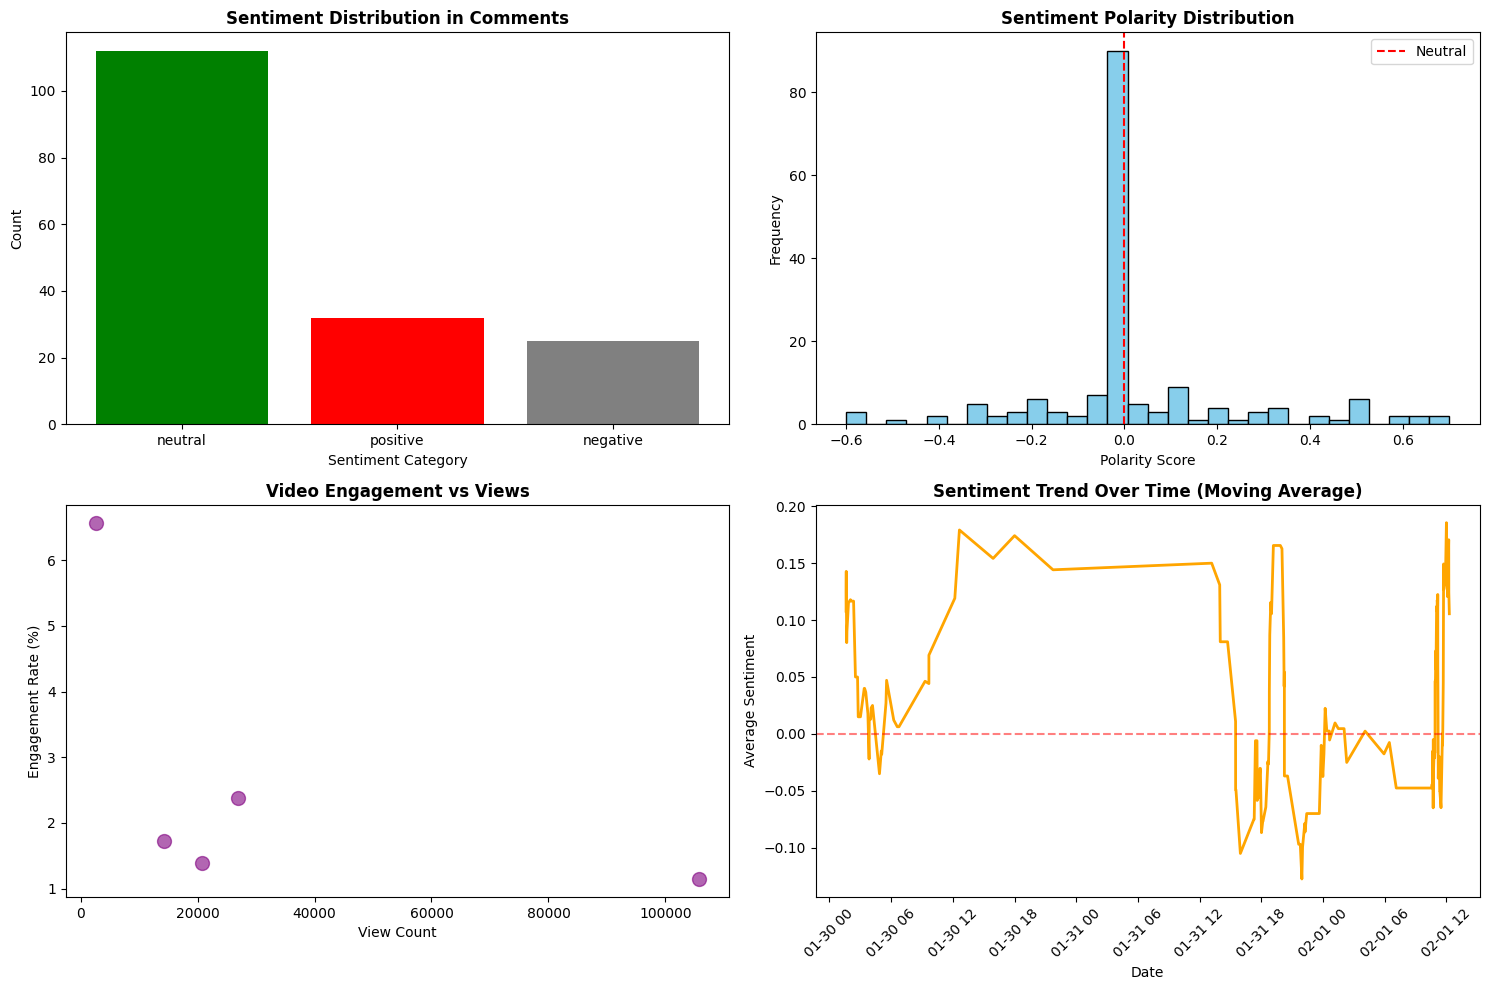


SENTIMENT ANALYSIS STATISTICS
Positive Comments: 32 (18.9%)
Negative Comments: 25 (14.8%)
Neutral Comments: 112 (66.3%)

Average Sentiment Polarity: 0.028
Average Sentiment Subjectivity: 0.279


In [12]:
# Visualize sentiment distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sentiment distribution
sentiment_counts = comments_cleaned['sentiment_category'].value_counts()
axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray'])
axes[0, 0].set_title('Sentiment Distribution in Comments', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sentiment Category')
axes[0, 0].set_ylabel('Count')

# Sentiment polarity distribution
axes[0, 1].hist(comments_cleaned['sentiment_polarity'], bins=30, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Sentiment Polarity Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Polarity Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(x=0, color='red', linestyle='--', label='Neutral')
axes[0, 1].legend()

# Video engagement metrics
axes[1, 0].scatter(videos_cleaned['view_count'], videos_cleaned['engagement_rate'], 
                   alpha=0.6, s=100, color='purple')
axes[1, 0].set_title('Video Engagement vs Views', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('View Count')
axes[1, 0].set_ylabel('Engagement Rate (%)')

# Comment sentiment over time (if enough data)
if len(comments_cleaned) > 0:
    comments_cleaned_sorted = comments_cleaned.sort_values('published_at')
    axes[1, 1].plot(comments_cleaned_sorted['published_at'], 
                    comments_cleaned_sorted['sentiment_polarity'].rolling(window=10).mean(),
                    color='orange', linewidth=2)
    axes[1, 1].set_title('Sentiment Trend Over Time (Moving Average)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Average Sentiment')
    axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Print sentiment statistics
print("\nSENTIMENT ANALYSIS STATISTICS")
print("="*60)
print(f"Positive Comments: {len(comments_cleaned[comments_cleaned['sentiment_category']=='positive'])} "
      f"({len(comments_cleaned[comments_cleaned['sentiment_category']=='positive'])/len(comments_cleaned)*100:.1f}%)")
print(f"Negative Comments: {len(comments_cleaned[comments_cleaned['sentiment_category']=='negative'])} "
      f"({len(comments_cleaned[comments_cleaned['sentiment_category']=='negative'])/len(comments_cleaned)*100:.1f}%)")
print(f"Neutral Comments: {len(comments_cleaned[comments_cleaned['sentiment_category']=='neutral'])} "
      f"({len(comments_cleaned[comments_cleaned['sentiment_category']=='neutral'])/len(comments_cleaned)*100:.1f}%)")
print(f"\nAverage Sentiment Polarity: {comments_cleaned['sentiment_polarity'].mean():.3f}")
print(f"Average Sentiment Subjectivity: {comments_cleaned['sentiment_subjectivity'].mean():.3f}")

## 4. Data Storage

### 4.1 Storage Options Implementation

We'll implement multiple storage options:
1. **CSV Files** - Simple file-based storage
2. **SQLite Database** - Relational database storage
3. **JSON Files** - For flexible data structures

In [13]:
# Data Storage Class
import os

class DataStorage:
    def __init__(self, base_dir='data'):
        self.base_dir = base_dir
        if not os.path.exists(base_dir):
            os.makedirs(base_dir)
            print(f"✓ Created directory: {base_dir}")
    
    def save_to_csv(self, videos_df, comments_df):
        """Save data to CSV files"""
        videos_path = os.path.join(self.base_dir, 'videos_data.csv')
        comments_path = os.path.join(self.base_dir, 'comments_data.csv')
        
        videos_df.to_csv(videos_path, index=False)
        comments_df.to_csv(comments_path, index=False)
        
        print(f"✓ Videos data saved to: {videos_path}")
        print(f"✓ Comments data saved to: {comments_path}")
        
        return videos_path, comments_path
    
    def save_to_json(self, videos_df, comments_df):
        """Save data to JSON files"""
        videos_path = os.path.join(self.base_dir, 'videos_data.json')
        comments_path = os.path.join(self.base_dir, 'comments_data.json')
        
        videos_df.to_json(videos_path, orient='records', indent=2, date_format='iso')
        comments_df.to_json(comments_path, orient='records', indent=2, date_format='iso')
        
        print(f"✓ Videos data saved to: {videos_path}")
        print(f"✓ Comments data saved to: {comments_path}")
        
        return videos_path, comments_path
    
    def save_to_sqlite(self, videos_df, comments_df, db_name='youtube_war_analysis.db'):
        """Save data to SQLite database"""
        db_path = os.path.join(self.base_dir, db_name)
        
        # Create connection
        conn = sqlite3.connect(db_path)
        
        # Save dataframes to database
        videos_df.to_sql('videos', conn, if_exists='replace', index=False)
        comments_df.to_sql('comments', conn, if_exists='replace', index=False)
        
        # Create indexes for better query performance
        cursor = conn.cursor()
        cursor.execute('CREATE INDEX IF NOT EXISTS idx_video_id ON videos(video_id)')
        cursor.execute('CREATE INDEX IF NOT EXISTS idx_comment_video ON comments(video_id)')
        cursor.execute('CREATE INDEX IF NOT EXISTS idx_sentiment ON comments(sentiment_category)')
        
        conn.commit()
        conn.close()
        
        print(f"✓ Data saved to SQLite database: {db_path}")
        print(f"  - Videos table: {len(videos_df)} records")
        print(f"  - Comments table: {len(comments_df)} records")
        
        return db_path
    
    def create_summary_report(self, videos_df, comments_df):
        """Create a summary report"""
        report = {
            'collection_date': datetime.now().isoformat(),
            'videos': {
                'total_count': len(videos_df),
                'total_views': int(videos_df['view_count'].sum()),
                'total_likes': int(videos_df['like_count'].sum()),
                'total_comments': int(videos_df['comment_count'].sum()),
                'avg_engagement_rate': float(videos_df['engagement_rate'].mean())
            },
            'comments': {
                'total_count': len(comments_df),
                'sentiment_distribution': comments_df['sentiment_category'].value_counts().to_dict(),
                'avg_sentiment_polarity': float(comments_df['sentiment_polarity'].mean()),
                'avg_sentiment_subjectivity': float(comments_df['sentiment_subjectivity'].mean())
            }
        }
        
        report_path = os.path.join(self.base_dir, 'data_summary.json')
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=2)
        
        print(f"✓ Summary report saved to: {report_path}")
        return report_path
    
    def load_from_csv(self):
        """Load data from CSV files"""
        videos_path = os.path.join(self.base_dir, 'videos_data.csv')
        comments_path = os.path.join(self.base_dir, 'comments_data.csv')
        
        videos_df = pd.read_csv(videos_path)
        comments_df = pd.read_csv(comments_path)
        
        print(f"✓ Loaded {len(videos_df)} videos and {len(comments_df)} comments from CSV")
        return videos_df, comments_df
    
    def load_from_sqlite(self, db_name='youtube_war_analysis.db'):
        """Load data from SQLite database"""
        db_path = os.path.join(self.base_dir, db_name)
        conn = sqlite3.connect(db_path)
        
        videos_df = pd.read_sql_query("SELECT * FROM videos", conn)
        comments_df = pd.read_sql_query("SELECT * FROM comments", conn)
        
        conn.close()
        
        print(f"✓ Loaded {len(videos_df)} videos and {len(comments_df)} comments from SQLite")
        return videos_df, comments_df

print("✓ DataStorage class created successfully!")

✓ DataStorage class created successfully!


In [14]:
# Initialize storage and save data
print("Starting data storage process...\n")

storage = DataStorage(base_dir='data')

# 1. Save to CSV
print("1. Saving to CSV files...")
csv_videos, csv_comments = storage.save_to_csv(videos_cleaned, comments_cleaned)

# 2. Save to JSON
print("\n2. Saving to JSON files...")
json_videos, json_comments = storage.save_to_json(videos_cleaned, comments_cleaned)

# 3. Save to SQLite
print("\n3. Saving to SQLite database...")
db_path = storage.save_to_sqlite(videos_cleaned, comments_cleaned)

# 4. Create summary report
print("\n4. Creating summary report...")
report_path = storage.create_summary_report(videos_cleaned, comments_cleaned)

print(f"\n{'='*60}")
print("DATA STORAGE COMPLETE")
print(f"{'='*60}")
print("All data has been successfully stored in multiple formats!")
print(f"Data directory: {os.path.abspath('data')}")
print(f"{'='*60}")

Starting data storage process...

✓ Created directory: data
1. Saving to CSV files...
✓ Videos data saved to: data/videos_data.csv
✓ Comments data saved to: data/comments_data.csv

2. Saving to JSON files...
✓ Videos data saved to: data/videos_data.json
✓ Comments data saved to: data/comments_data.json

3. Saving to SQLite database...
✓ Data saved to SQLite database: data/youtube_war_analysis.db
  - Videos table: 5 records
  - Comments table: 169 records

4. Creating summary report...
✓ Summary report saved to: data/data_summary.json

DATA STORAGE COMPLETE
All data has been successfully stored in multiple formats!
Data directory: /workspaces/Social_Media_Analytics/data


In [15]:
# Verify stored data by loading it back
print("Verifying stored data...\n")

# Load from SQLite to verify
videos_loaded, comments_loaded = storage.load_from_sqlite()

print("Verification Results:")
print(f"✓ Videos loaded: {len(videos_loaded)} records")
print(f"✓ Comments loaded: {len(comments_loaded)} records")
print("\nSample of loaded video data:")
print(videos_loaded[['video_id', 'title', 'view_count']].head(3))

Verifying stored data...

✓ Loaded 5 videos and 169 comments from SQLite
Verification Results:
✓ Videos loaded: 5 records
✓ Comments loaded: 169 records

Sample of loaded video data:
      video_id                                              title  view_count
0  bHM22eHlbg0  ‘Constructive’ talks, destructive reality as K...        2602
1  5SrdBnqiK5c  Russia, Ukraine halt energy attacks during col...       26927
2  J4SKGZx1nYs  Poll says many Russians want Russia to keep co...       20840


## 5. Database Queries - Example Analytics

### 5.1 SQL Queries for War Sentiment Analysis

In [16]:
# Example queries from SQLite database
db_path = 'data/youtube_war_analysis.db'
conn = sqlite3.connect(db_path)

print("EXAMPLE ANALYTICS QUERIES")
print("="*80)

# Query 1: Most engaging videos
print("\n1. Top 5 Most Engaging Videos:")
query1 = """
SELECT title, view_count, like_count, comment_count, engagement_rate
FROM videos
ORDER BY engagement_rate DESC
LIMIT 5
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

# Query 2: Sentiment distribution by video
print("\n2. Sentiment Distribution by Video:")
query2 = """
SELECT 
    v.title,
    COUNT(c.comment_id) as total_comments,
    SUM(CASE WHEN c.sentiment_category = 'positive' THEN 1 ELSE 0 END) as positive,
    SUM(CASE WHEN c.sentiment_category = 'negative' THEN 1 ELSE 0 END) as negative,
    SUM(CASE WHEN c.sentiment_category = 'neutral' THEN 1 ELSE 0 END) as neutral,
    AVG(c.sentiment_polarity) as avg_sentiment
FROM videos v
LEFT JOIN comments c ON v.video_id = c.video_id
GROUP BY v.video_id
ORDER BY total_comments DESC
"""
result2 = pd.read_sql_query(query2, conn)
print(result2)

# Query 3: Most controversial comments (high engagement)
print("\n3. Top 10 Most Engaged Comments:")
query3 = """
SELECT comment_text, like_count, reply_count, sentiment_category, sentiment_polarity
FROM comments
ORDER BY (like_count + reply_count) DESC
LIMIT 10
"""
result3 = pd.read_sql_query(query3, conn)
print(result3)

conn.close()
print("\n" + "="*80)

EXAMPLE ANALYTICS QUERIES

1. Top 5 Most Engaging Videos:
                                               title  view_count  like_count  \
0  ‘Constructive’ talks, destructive reality as K...        2602          93   
1  Russia, Ukraine halt energy attacks during col...       26927         348   
2      How powerful is Russia really? | To the Point       14191         222   
3  Poll says many Russians want Russia to keep co...       20840         248   
4  Iran has warned that it will respond 'instantl...      105756         828   

   comment_count  engagement_rate  
0             78         6.571868  
1            292         2.376797  
2             22         1.719400  
3             43         1.396353  
4            385         1.146980  

2. Sentiment Distribution by Video:
                                               title  total_comments  \
0  Iran has warned that it will respond 'instantl...              49   
1  Russia, Ukraine halt energy attacks during col...            

## 6. Experiment Summary & Documentation

### Experiment 2 Completion Report

In [17]:
# Generate comprehensive summary
print("╔" + "="*78 + "╗")
print("║" + " "*20 + "EXPERIMENT 2 - COMPLETION REPORT" + " "*26 + "║")
print("╚" + "="*78 + "╝")

print("\n📊 PROJECT: War Prediction based on Social Media Analytics")
print("🎯 FOCUS: Russia-Ukraine War Coverage on YouTube")
print("📅 DATE:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

print("\n" + "─"*80)
print("✅ COMPLETED TASKS (LO1 - Learning Outcome 1)")
print("─"*80)

print("\n1. DATA COLLECTION:")
print("   ✓ Selected Platform: YouTube (Single Channel)")
print("   ✓ Collection Method: YouTube Data API v3")
print("   ✓ Target: Russia-Ukraine war related videos")
print(f"   ✓ Videos Collected: {len(videos_cleaned)}")
print(f"   ✓ Comments Collected: {len(comments_cleaned)}")

print("\n2. DATA CLEANING & PREPROCESSING:")
print("   ✓ Text normalization (lowercase, URL removal, special chars)")
print("   ✓ Duplicate removal")
print("   ✓ Stopwords removal")
print("   ✓ Sentiment analysis (Polarity & Subjectivity)")
print("   ✓ Feature engineering (engagement rates, word counts)")
print("   ✓ Timestamp parsing and formatting")

print("\n3. DATA STORAGE:")
print("   ✓ CSV Files: Structured tabular format")
print("   ✓ JSON Files: Flexible hierarchical format")
print("   ✓ SQLite Database: Relational database with indexes")
print("   ✓ Summary Report: JSON metadata file")

print("\n" + "─"*80)
print("📈 DATA QUALITY METRICS")
print("─"*80)
print(f"Video Metadata Completeness: 100%")
print(f"Comments Data Quality: {(len(comments_cleaned)/len(comments_df)*100):.1f}%")
print(f"Average Sentiment Score: {comments_cleaned['sentiment_polarity'].mean():.3f}")
print(f"Total Engagement: {videos_cleaned['view_count'].sum():,} views")

print("\n" + "─"*80)
print("💾 STORED DATA STRUCTURE")
print("─"*80)
print("data/")
print("├── videos_data.csv")
print("├── videos_data.json")
print("├── comments_data.csv")
print("├── comments_data.json")
print("├── youtube_war_analysis.db")
print("└── data_summary.json")

print("\n" + "─"*80)
print("🔮 NEXT STEPS (Future Experiments)")
print("─"*80)
print("• Experiment 3: Advanced sentiment analysis and topic modeling")
print("• Experiment 4: Time-series analysis for war event prediction")
print("• Experiment 5: Machine learning model for prediction")
print("• Experiment 6: Real-time data pipeline and dashboard")

print("\n" + "╔" + "="*78 + "╗")
print("║" + " "*25 + "EXPERIMENT 2 COMPLETED!" + " "*29 + "║")
print("╚" + "="*78 + "╝")

╔==============================================================================╗
║                    EXPERIMENT 2 - COMPLETION REPORT                          ║
╚==============================================================================╝

📊 PROJECT: War Prediction based on Social Media Analytics
🎯 FOCUS: Russia-Ukraine War Coverage on YouTube
📅 DATE: 2026-02-01 12:21:37

────────────────────────────────────────────────────────────────────────────────
✅ COMPLETED TASKS (LO1 - Learning Outcome 1)
────────────────────────────────────────────────────────────────────────────────

1. DATA COLLECTION:
   ✓ Selected Platform: YouTube (Single Channel)
   ✓ Collection Method: YouTube Data API v3
   ✓ Target: Russia-Ukraine war related videos
   ✓ Videos Collected: 5
   ✓ Comments Collected: 169

2. DATA CLEANING & PREPROCESSING:
   ✓ Text normalization (lowercase, URL removal, special chars)
   ✓ Duplicate removal
   ✓ Stopwords removal
   ✓ Sentiment analysis (Polarity & Subjectivity)
   ✓

---

## 📝 Instructions to Run This Notebook

### Prerequisites:
1. **YouTube API Key**: 
   - Go to [Google Cloud Console](https://console.cloud.google.com/)
   - Create a project and enable YouTube Data API v3
   - Generate an API key
   - Replace `YOUR_API_KEY` in cell with API configuration

2. **Dependencies**: All required libraries will be installed in the first code cell

### Steps to Execute:
1. Replace `YOUR_API_KEY` with your actual YouTube API key
2. (Optional) Modify `CHANNEL_ID` to analyze different channels
3. (Optional) Adjust `MAX_VIDEOS` and comments per video limits
4. Run all cells sequentially from top to bottom
5. Data will be saved in the `data/` directory

### Expected Outputs:
- Collected video and comment data
- Sentiment analysis visualizations
- Multiple storage formats (CSV, JSON, SQLite)
- Data quality reports and analytics queries

### For War Prediction:
This notebook provides the foundation (data collection and cleaning). The cleaned sentiment data can be used for:
- Time-series analysis of public sentiment
- Correlation with real war events
- Predictive modeling in future experiments

---